# Toxic Comment Multi-Label Classification

Run **Kernel → Restart & Run All** to execute the full pipeline end-to-end.

Pipeline:
1. Setup & Import
2. Load Dataset
3. Traditional Pipeline (TF-IDF + Logistic Regression + Optuna)
4. Deep Learning Pipeline (DistilRoBERTa embeddings + PyTorch)

In [1]:
import os
import sys
import time
import warnings

# Tắt cảnh báo và thêm thư mục gốc vào đường dẫn để import được các modules
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # <-- Đã thêm thư viện vẽ đồ thị
import nltk

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# <-- Đã bổ sung thêm các hàm vẽ ROC và Precision-Recall
from sklearn.metrics import (
    classification_report, f1_score, precision_score, recall_score,
    roc_auc_score, accuracy_score, hamming_loss, precision_recall_fscore_support,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# Tải trước các gói ngôn ngữ cần thiết cho xử lý văn bản
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)


from modules.preprocess_data import normalize_text, clean_text_dl
from modules.traditional_pipeline import fit_tfidf, run_optuna_training
from modules.deep_learning_pipeline import (
    extract_sentence_embeddings,
    DeepLogisticRegression,
    train_dl_model,
    evaluate_dl_model,
)

print('[INFO] Environment setup complete!')

[INFO] Environment setup complete!


# Load Dataset

In [2]:
train_df = pd.read_csv('../data/raw/train.csv')
test_df  = pd.read_csv('../data/raw/test.csv')

print('Train:', train_df.shape)
print('Test: ', test_df.shape)

label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
X_train = train_df['comment_text'].values
X_test  = test_df['comment_text'].values
y_train = train_df[label_cols]

print('Number of Null values:', train_df.isnull().sum().values.sum())

counts = train_df[label_cols].sum(axis=1).value_counts().sort_index()
print('Label count distribution (%):')
print((counts / len(train_df) * 100).round(2))

multi = (train_df[label_cols].sum(axis=1) > 1).mean()
print('Fraction of rows with multiple labels:', round(multi, 4))

train_df['is_toxic'] = train_df[label_cols].max(axis=1)
toxic_df = train_df[train_df['is_toxic'] == 1]
clean_df  = train_df[train_df['is_toxic'] == 0]
print('Toxic:', toxic_df.shape, '| Clean:', clean_df.shape)

Train: (159571, 8)
Test:  (153164, 2)
Number of Null values: 0
Label count distribution (%):
0    89.83
1     3.99
2     2.18
3     2.64
4     1.10
5     0.24
6     0.02
Name: count, dtype: float64
Fraction of rows with multiple labels: 0.0618
Toxic: (16225, 9) | Clean: (143346, 9)


---
# Traditional Pipeline
## Step 1 — Text Preprocessing & Tokenization

Uses `normalize_text` from `modules/preprocess_data.py`:
lower-case → unidecode → contractions → HTML-unescape → strip HTML/URLs/IPs → remove punctuation → stopword removal → Porter stemming.

In [3]:
import os, pickle, gc
from tqdm.auto import tqdm

NORMALIZED_PATH = "../features/normalized_texts.pkl"
os.makedirs("../features", exist_ok=True)

if os.path.exists(NORMALIZED_PATH):
    print("[INFO] Found cached traditional pre-processed texts. Loading from disk...")
    with open(NORMALIZED_PATH, "rb") as f:
        _data = pickle.load(f)
    X_normalize = _data["X_normalize"]
    X_test_normalize = _data["X_test_normalize"]
    print(f"[INFO] Successfully loaded {len(X_normalize):,} train and {len(X_test_normalize):,} test records.")
else:
    print("[INFO] No cache found. Starting text normalization for Traditional Pipeline...")
    
    X_normalize = []
    for i, text in enumerate(tqdm(X_train, desc="Normalizing Train")):
        try:
            X_normalize.append(normalize_text(str(text)[:1500]))
        except Exception:
            X_normalize.append("")
        if i % 10000 == 0: gc.collect()

    X_test_normalize = []
    for i, text in enumerate(tqdm(X_test, desc="Normalizing Test ")):
        try:
            X_test_normalize.append(normalize_text(str(text)[:1500]))
        except Exception:
            X_test_normalize.append("")
        if i % 10000 == 0: gc.collect()

    with open(NORMALIZED_PATH, "wb") as f:
        pickle.dump({"X_normalize": X_normalize, "X_test_normalize": X_test_normalize}, f)
    print("[INFO] Normalization complete. Data cached successfully.")

print(f"\n[Sample - Traditional] {X_normalize[0]}")

[INFO] Found cached traditional pre-processed texts. Loading from disk...
[INFO] Successfully loaded 159,571 train and 153,164 test records.

[Sample - Traditional] explan edit made usernam hardcor metallica fan revert not vandal closur ga vote new york doll fac pleas not remov templat talk page sinc retir


## Step 2 — Feature Extraction (TF-IDF)

Uses `fit_tfidf` from `modules/traditional_pipeline.py`.  
Saves sparse matrices to `../features/tfidf_*.h5`.

In [4]:
X_train_tfidf, X_test_tfidf, tfidf = fit_tfidf(
    X_normalize,
    X_test_normalize,
    max_features=10000,
    features_dir='../features',
)

Fitting TF-IDF on training data...
  X_train shape: (159571, 10000)
Transforming test data...
  X_test shape:  (153164, 10000)
Saved TF-IDF embeddings to '../features/'


## Step 3 — End-to-End Training (Optuna + Threshold Tuning)

Uses `run_optuna_training` from `modules/traditional_pipeline.py`.

- Multilabel-stratified split (80/20 → tune/report)
- Optuna hyperparameter search (3-fold CV)
- Per-label threshold tuning
- Evaluation on holdout split
- Retrain on 100 % → save `../models/test_pred_proba.csv`, `best_thresholds.csv`

> Set `n_trials` lower (e.g. 5) for a quick test run.

In [5]:
trad_model, best_thresholds = run_optuna_training(
    X_train_tfidf,
    X_test_tfidf,
    y_all=train_df[label_cols],
    test_df=test_df,
    label_cols=label_cols,
    models_dir='../models',
    n_trials=20,
)

Starting Optuna Hyperparameter Optimization...
Optimization complete! Best params: {'C': 1.6910623336217812, 'penalty': 'l2', 'solver': 'lbfgs'}
Training final model with best parameters...
Final model trained successfully!
Tuning per-label thresholds on threshold-tuning split...
Best per-label thresholds: {'toxic': 0.8000000000000006, 'severe_toxic': 0.9450000000000007, 'obscene': 0.8300000000000006, 'threat': 0.8300000000000006, 'insult': 0.8450000000000006, 'identity_hate': 0.9400000000000007}

Evaluating on holdout report split...
               precision    recall  f1-score   support

        toxic       0.82      0.73      0.77      1530
 severe_toxic       0.40      0.64      0.49       160
      obscene       0.83      0.80      0.81       845
       threat       0.25      0.50      0.33        48
       insult       0.67      0.73      0.70       788
identity_hate       0.41      0.50      0.45       141

    micro avg       0.72      0.73      0.72      3512
    macro avg    

---
# Deep Learning Pipeline
## Step 1 — Text Preprocessing

Uses `clean_text_dl` from `modules/preprocess_data.py`:
HTML-unescape → strip HTML/URLs → unidecode → contractions → lower-case → remove special chars.

In [6]:
import os, pickle, gc
from tqdm.auto import tqdm

DL_CLEAN_PATH = "../features/dl_clean_texts.pkl"
os.makedirs("../features", exist_ok=True)

if os.path.exists(DL_CLEAN_PATH):
    print("[INFO] Found cached Deep Learning pre-processed texts. Loading from disk...")
    with open(DL_CLEAN_PATH, "rb") as f:
        _data = pickle.load(f)
    X_clean = _data["X_clean"]
    X_test_clean = _data["X_test_clean"]
    print(f"[INFO] Successfully loaded {len(X_clean):,} train and {len(X_test_clean):,} test records.")
else:
    print("[INFO] No cache found. Starting text cleaning for Deep Learning Pipeline...")
    
    X_clean = []
    for i, text in enumerate(tqdm(X_train, desc="Cleaning Train (DL)")):
        try:
            X_clean.append(clean_text_dl(str(text)[:1500]))
        except Exception:
            X_clean.append("")
        if i % 10000 == 0: gc.collect()

    X_test_clean = []
    for i, text in enumerate(tqdm(X_test, desc="Cleaning Test  (DL)")):
        try:
            X_test_clean.append(clean_text_dl(str(text)[:1500]))
        except Exception:
            X_test_clean.append("")
        if i % 10000 == 0: gc.collect()

    with open(DL_CLEAN_PATH, "wb") as f:
        pickle.dump({"X_clean": X_clean, "X_test_clean": X_test_clean}, f)
    print("[INFO] DL Text cleaning complete. Data cached successfully.")

print(f"\n[Sample - Deep Learning] {X_clean[0]}")

[INFO] Found cached Deep Learning pre-processed texts. Loading from disk...
[INFO] Successfully loaded 159,571 train and 153,164 test records.

[Sample - Deep Learning] explanation why the edits made under my username hardcore metallica fan were reverted? they were not vandalisms, just closure on some gas after i voted at new york dolls fac. and please do not remove the template from the talk page since i am retired now.89.205.38.27


## Step 2 — Feature Extraction (DistilRoBERTa Embeddings)

Uses `extract_sentence_embeddings` from `modules/deep_learning_pipeline.py`.  
Model: `all-distilroberta-v1` → 768-dim vectors.  
Saves to `../features/X_train_embeddings.npy` and `X_test_embeddings.npy`.

In [7]:
X_train_embds, X_test_embds = extract_sentence_embeddings(
    X_clean,
    X_test_clean,
    features_dir='../features',
    model_name='all-distilroberta-v1',
)

Loading SentenceTransformer model: 'all-distilroberta-v1'
Encoding training data...


Batches:   0%|          | 0/4987 [00:00<?, ?it/s]

Encoding test data...


Batches:   0%|          | 0/4787 [00:00<?, ?it/s]

Training embeddings shape: (159571, 768)
Test embeddings shape:     (153164, 768)
Saved embeddings to '../features/'


## Step 3 — PyTorch Training

Uses `train_dl_model` from `modules/deep_learning_pipeline.py`.  
Architecture: single linear layer (`DeepLogisticRegression`) with `BCEWithLogitsLoss` + smoothed class weights.  
Saves model to `../models/pytorch_logreg_smoothed.pth`.

In [8]:
y_train_dl = train_df[label_cols].values[:X_train_embds.shape[0]]

dl_model, device = train_dl_model(
    X_train_dl=X_train_embds,
    y_train_dl=y_train_dl,
    models_dir='../models',
    epochs=30,
    batch_size=1024,
    lr=0.01,
)

Using device: cuda

STARTING PYTORCH TRAINING...
  Epoch [5/30] - Loss: 0.1511
  Epoch [10/30] - Loss: 0.1372
  Epoch [15/30] - Loss: 0.1316
  Epoch [20/30] - Loss: 0.1284
  Epoch [25/30] - Loss: 0.1263
  Epoch [30/30] - Loss: 0.1248
Training completed in 0.59 min. Saved to: ../models\pytorch_logreg_smoothed.pth


## Step 4 — Evaluation

Uses `evaluate_dl_model` from `modules/deep_learning_pipeline.py`.  
Merges predictions with ground-truth labels, removes Kaggle un-scored rows (-1),  
then calls `evaluation_metrics.export_metrics` for consistent reporting.  
Outputs saved to `../reports/evaluation_output_dl/`.

In [9]:
results_dl = evaluate_dl_model(
    dl_model=dl_model,
    device=device,
    X_test_dl=X_test_embds,
    test_df=test_df,
    label_cols=label_cols,
    truth_csv='../data/raw/test_labels.csv',
    models_dir='../models',
    reports_dir='../reports',
)

Generating predictions on the test set...
Saved prediction probabilities to '../models/test_pred_proba_dl.csv'
Evaluating comprehensive metrics...

--- DEEP LEARNING EVALUATION COMPLETE ---
Rows evaluated:   63978
Subset accuracy:  0.8476
Micro F1:         0.5782
Macro F1:         0.4877
Hamming loss:     0.0427
Macro ROC-AUC:    0.9704

Per-Label ROC-AUC:
  toxic          : 0.9472
  severe_toxic   : 0.9823
  obscene        : 0.9605
  threat         : 0.9885
  insult         : 0.9620
  identity_hate  : 0.9818
----------------------------------------

               precision    recall  f1-score   support

        toxic       0.50      0.80      0.61      6090
 severe_toxic       0.17      0.78      0.28       367
      obscene       0.52      0.76      0.62      3691
       threat       0.26      0.73      0.38       211
       insult       0.51      0.75      0.60      3427
identity_hate       0.29      0.79      0.42       712

    micro avg       0.46      0.78      0.58     14498
 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import f1_score, classification_report

print("[INFO] Starting Per-Label Threshold Tuning for Deep Learning...")

# 1. Đọc dữ liệu dự đoán (Xác suất) và dữ liệu thật
truth_df = pd.read_csv('../data/raw/test_labels.csv')
pred_proba_df = pd.read_csv('../models/test_pred_proba_dl.csv')

# Ghép data, loại bỏ các dòng Kaggle không chấm điểm (-1)
merged = pd.merge(truth_df, pred_proba_df, on='id', suffixes=('_true', '_pred'))
clean_df = merged[merged['toxic_true'] != -1].copy()

label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
best_thresholds_dl = {}
y_pred_binary = np.zeros((len(clean_df), len(label_cols)))

# 2. Quét Threshold từ 0.1 đến 0.95 cho từng nhãn
threshold_grid = np.arange(0.1, 0.95, 0.05)

for idx, label in enumerate(label_cols):
    y_true = clean_df[f'{label}_true'].values
    y_proba = clean_df[f'{label}_pred'].values
    
    best_t = 0.5
    best_f1 = 0.0
    
    for t in threshold_grid:
        current_pred = (y_proba >= t).astype(int)
        current_f1 = f1_score(y_true, current_pred, zero_division=0)
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_t = t
            
    best_thresholds_dl[label] = best_t
    y_pred_binary[:, idx] = (y_proba >= best_t).astype(int)
    print(f"  - {label:<15} Optimal Threshold: {best_t:.2f} (F1: {best_f1:.4f})")

# 3. Lưu Threshold và in Classification Report mới
pd.DataFrame([best_thresholds_dl]).to_csv('../models/best_thresholds_dl.csv', index=False)
y_true_matrix = clean_df[[f'{l}_true' for l in label_cols]].values

print("\n--- DEEP LEARNING OPTIMIZED CLASSIFICATION REPORT ---")
print(classification_report(y_true_matrix, y_pred_binary, target_names=label_cols, zero_division=0))

[INFO] Starting Per-Label Threshold Tuning for Deep Learning...
  - toxic           Optimal Threshold: 0.75 (F1: 0.6467)
  - severe_toxic    Optimal Threshold: 0.85 (F1: 0.3711)
  - obscene         Optimal Threshold: 0.75 (F1: 0.6512)
  - threat          Optimal Threshold: 0.80 (F1: 0.4661)
  - insult          Optimal Threshold: 0.70 (F1: 0.6270)
  - identity_hate   Optimal Threshold: 0.80 (F1: 0.5173)

--- DEEP LEARNING OPTIMIZED CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

        toxic       0.62      0.67      0.65      6090
 severe_toxic       0.29      0.52      0.37       367
      obscene       0.66      0.64      0.65      3691
       threat       0.40      0.55      0.47       211
       insult       0.61      0.64      0.63      3427
identity_hate       0.46      0.60      0.52       712

    micro avg       0.60      0.65      0.62     14498
    macro avg       0.51      0.60      0.55     14498
 weighted avg       0.61      0.65      0.

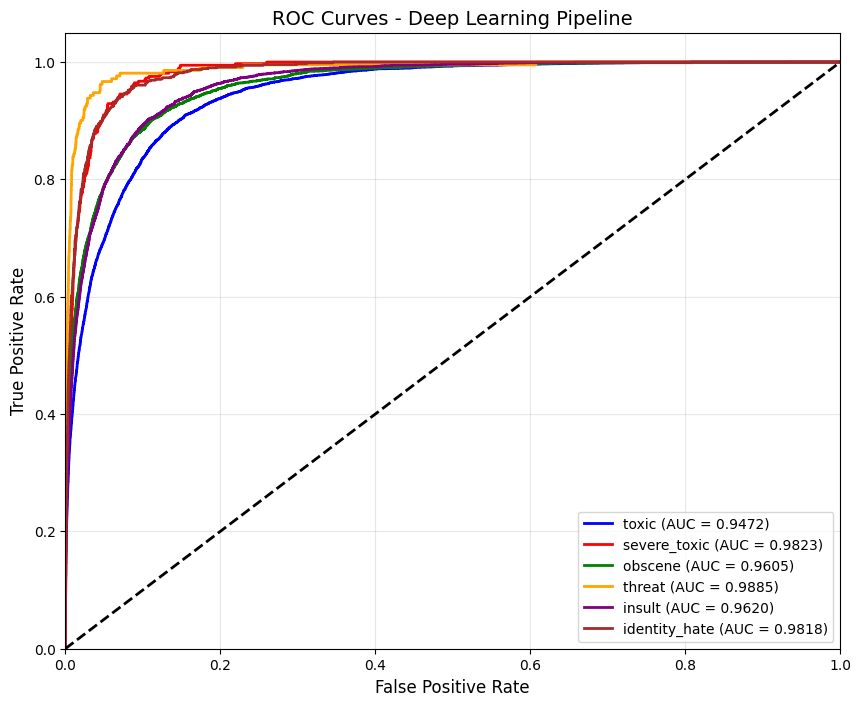

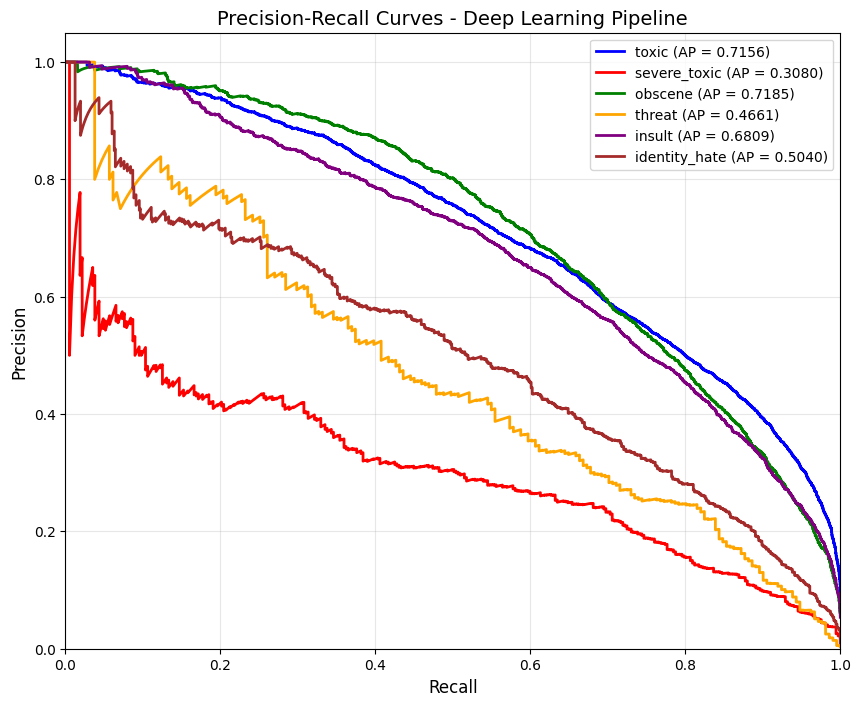

[INFO] Curves saved successfully to '../reports/evaluation_output_dl/'


In [12]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

os.makedirs('../reports/evaluation_output_dl', exist_ok=True)

# Cài đặt màu sắc cho 6 nhãn
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

# --- VẼ ROC CURVES ---
plt.figure(figsize=(10, 8))
for idx, (label, color) in enumerate(zip(label_cols, colors)):
    y_true = clean_df[f'{label}_true'].values
    y_proba = clean_df[f'{label}_pred'].values
    
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Deep Learning Pipeline', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('../reports/evaluation_output_dl/roc_curves_dl.png', dpi=300, bbox_inches='tight')
plt.show()

# --- VẼ PRECISION-RECALL CURVES ---
plt.figure(figsize=(10, 8))
for idx, (label, color) in enumerate(zip(label_cols, colors)):
    y_true = clean_df[f'{label}_true'].values
    y_proba = clean_df[f'{label}_pred'].values
    
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    
    plt.plot(recall, precision, color=color, lw=2, label=f'{label} (AP = {pr_auc:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves - Deep Learning Pipeline', fontsize=14)
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.savefig('../reports/evaluation_output_dl/pr_curves_dl.png', dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] Curves saved successfully to '../reports/evaluation_output_dl/'")